# 🏆 IMC Prosperity — Round 1 Market Analysis

**Products:** `INTARIAN_PEPPER_ROOT` · `ASH_COATED_OSMIUM`  
**Days:** Day -2, Day -1, Day 0  

---

### What this notebook covers
1. **Data loading & overview** — shape, products, basic stats
2. **Missing bid/ask analysis** — where is the order book thin or empty?
3. **Mid-price trends** — how prices evolve across days
4. **Bid-ask spread** — how wide is the market?
5. **Order book depth** — how many levels are active?
6. **Trade flow** — volume, frequency, price distribution
7. **Key takeaways**


## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})

# Product colours — tweak as you like
COLORS = {
    'INTARIAN_PEPPER_ROOT': '#c39f2b',   # gold
    'ASH_COATED_OSMIUM':    '#3a7abf',   # steel blue
}
DAY_COLORS = {-2: '#555', -1: '#888', 0: '#bbb'}

# ── File paths — adjust if you move the CSVs ─────────────────────────────────
PRICE_FILES = [
    'prices_round_1_day_-2.csv',
    'prices_round_1_day_-1.csv',
    'prices_round_1_day_0.csv',
]
TRADE_FILES = [
    'trades_round_1_day_-2.csv',
    'trades_round_1_day_-1.csv',
    'trades_round_1_day_0.csv',
]

print('Setup complete ✓')


Setup complete ✓


## 1. Data Loading & Overview

We concatenate the three days into a single DataFrame for each file type.  
The separator is **`;`** (semicolon), not a comma.


In [2]:
# --- Prices ---
price_dfs = []
for f in PRICE_FILES:
    df = pd.read_csv(f, sep=';')
    price_dfs.append(df)
prices = pd.concat(price_dfs, ignore_index=True)

# --- Trades ---
trade_dfs = []
for f in TRADE_FILES:
    df = pd.read_csv(f, sep=';')
    trade_dfs.append(df)
trades = pd.concat(trade_dfs, ignore_index=True)

print(f'Prices : {len(prices):,} rows × {len(prices.columns)} cols')
print(f'Trades : {len(trades):,} rows × {len(trades.columns)} cols')
print()
print('Products:', prices['product'].unique().tolist())
print('Days    :', sorted(prices['day'].unique().tolist()))
prices.head()


Prices : 60,000 rows × 17 cols
Trades : 2,276 rows × 7 cols

Products: ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Days    : [-2, -1, 0]


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0


In [3]:
# Basic stats for mid-price per product × day
prices.groupby(['product', 'day'])['mid_price'].describe().round(2)


count      mean     std  min       25%      50%  \
product              day                                                      
ASH_COATED_OSMIUM    -2   10000.0   9980.17  423.86  0.0   9994.50   9998.0   
                     -1   10000.0   9983.83  412.04  0.0   9998.00  10001.0   
                      0   10000.0   9987.61  374.03  0.0   9998.00  10002.0   
INTARIAN_PEPPER_ROOT -2   10000.0  10483.16  509.28  0.0  10248.50  10499.0   
                     -1   10000.0  11480.48  554.67  0.0  11249.38  11499.5   
                      0   10000.0  12473.92  640.83  0.0  12248.50  12499.0   

                               75%      max  
product              day                     
ASH_COATED_OSMIUM    -2   10002.00  10019.0  
                     -1   10003.00  10019.0  
                      0   10005.00  10023.0  
INTARIAN_PEPPER_ROOT -2   10749.62  11003.0  
                     -1   11749.50  12006.0  
                      0   12750.00  13007.0

## 2. Missing Bid / Ask Analysis

In this data, **NaN** in a bid/ask column simply means that level of the order book was **empty** at that timestamp — not a data error.  
Understanding *how often* each level is missing tells us how deep the market is in practice.


In [4]:
bid_cols = ['bid_price_1', 'bid_price_2', 'bid_price_3']
ask_cols = ['ask_price_1', 'ask_price_2', 'ask_price_3']

rows = []
for prod, sub in prices.groupby('product'):
    total = len(sub)
    for col in bid_cols + ask_cols:
        n_miss = sub[col].isna().sum()
        rows.append({'product': prod, 'column': col,
                     'missing': n_miss, 'pct_missing': round(100 * n_miss / total, 1),
                     'pct_present': round(100 * (1 - n_miss / total), 1)})

miss_df = pd.DataFrame(rows)
print('\n=== % of timestamps where each order-book level IS PRESENT ===')
pivot = miss_df.pivot(index='column', columns='product', values='pct_present')
pivot.index.name = 'Level'
print(pivot.to_string())



=== % of timestamps where each order-book level IS PRESENT ===
product      ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
Level                                               
ask_price_1               96.0                  96.2
ask_price_2               65.2                  65.1
ask_price_3                2.5                   1.6
bid_price_1               96.0                  95.9
bid_price_2               65.3                  64.7
bid_price_3                2.6                   1.5


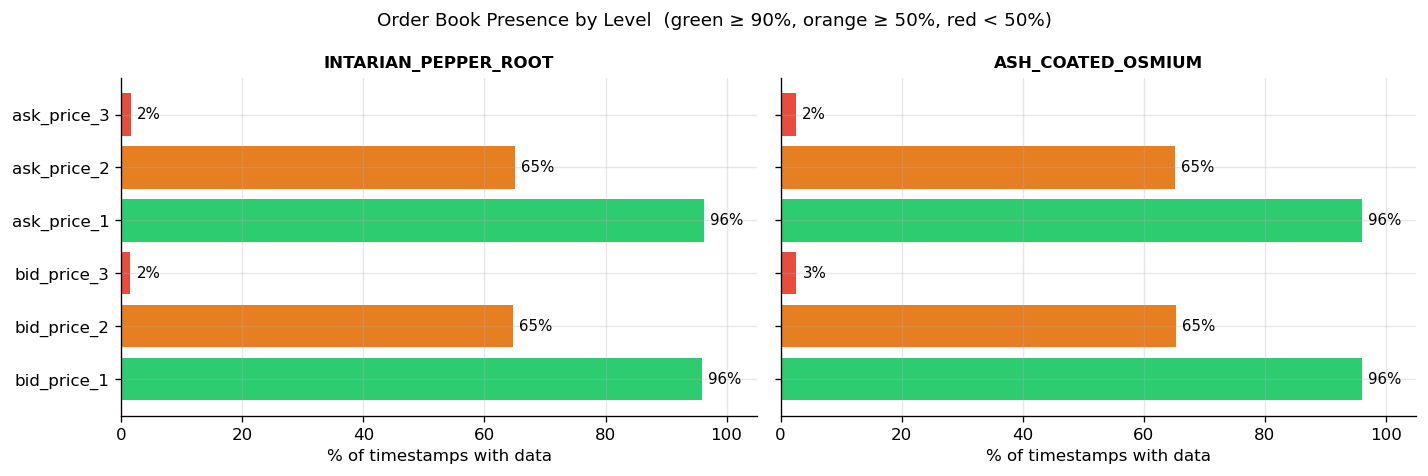

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, prod in zip(axes, prices['product'].unique()):
    sub = miss_df[miss_df['product'] == prod]
    cols = sub['column'].tolist()
    pcts = sub['pct_present'].tolist()
    bar_colors = ['#2ecc71' if p > 90 else '#e67e22' if p > 50 else '#e74c3c' for p in pcts]
    ax.barh(cols, pcts, color=bar_colors)
    ax.set_xlim(0, 105)
    ax.set_xlabel('% of timestamps with data')
    ax.set_title(prod, fontsize=10, fontweight='bold')
    # add value labels
    for i, (p, c) in enumerate(zip(pcts, cols)):
        ax.text(p + 1, i, f'{p:.0f}%', va='center', fontsize=9)

fig.suptitle('Order Book Presence by Level  (green ≥ 90%, orange ≥ 50%, red < 50%)', fontsize=11)
plt.tight_layout()
plt.show()


> **Key observation:**  
> - **Level 1** (best bid/ask) is present ~96% of the time — reliably liquid.  
> - **Level 2** drops to ~65% — sometimes only one side of the book exists.  
> - **Level 3** is almost always empty (~2%) — ignore it in strategies.


## 3. Mid-Price Trends Across Days

We plot the mid-price over the full timestamp range, one series per day.  
This quickly shows if prices drift, mean-revert, or follow a trend.


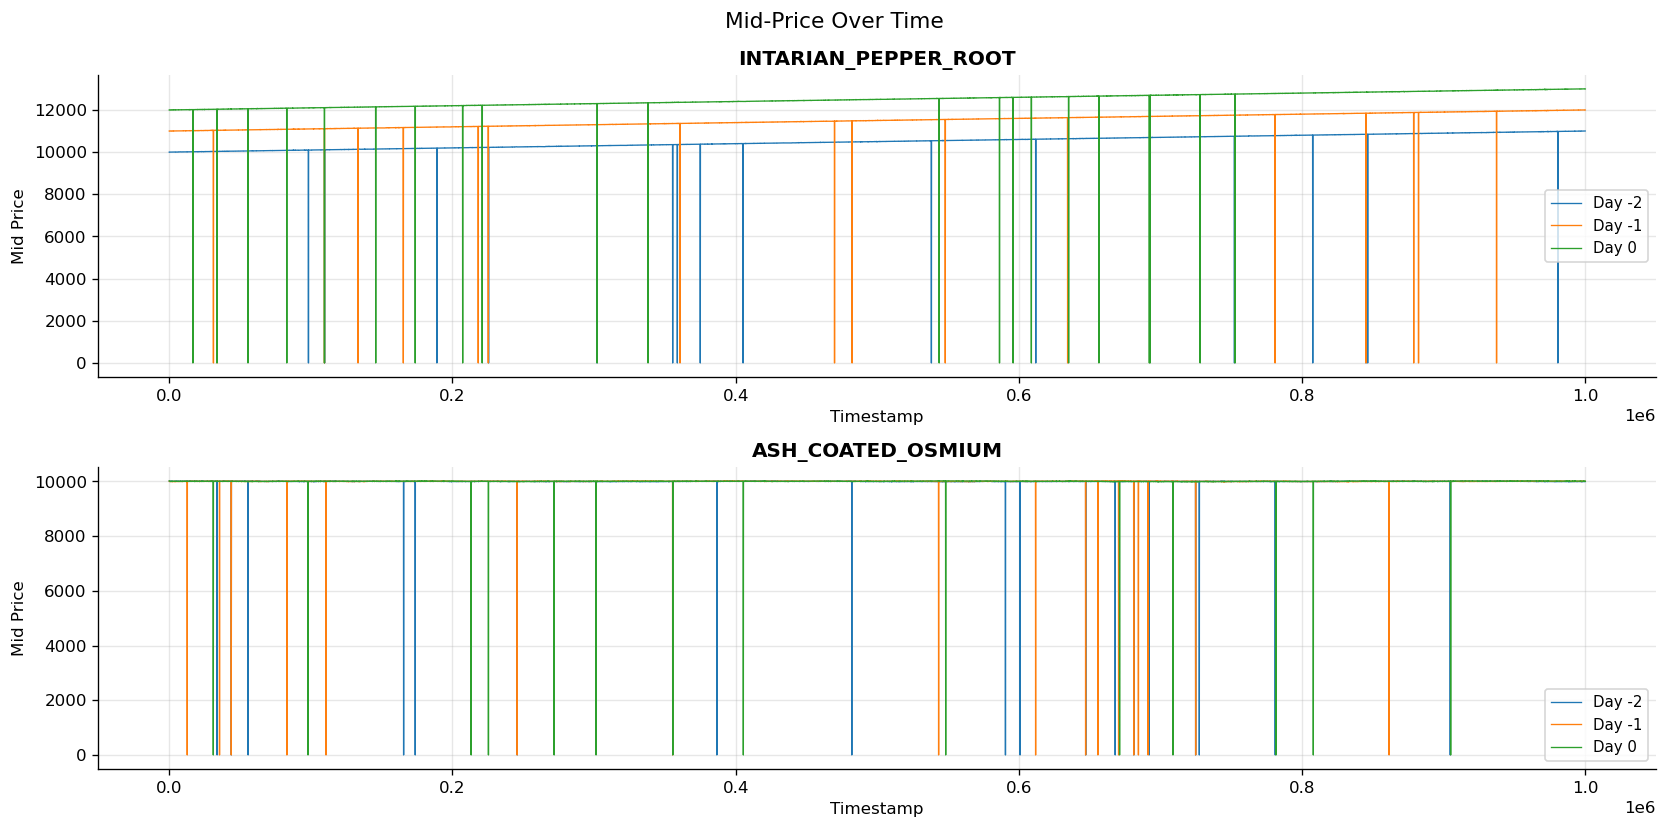

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, prod in zip(axes, prices['product'].unique()):
    sub = prices[prices['product'] == prod]
    for day, grp in sub.groupby('day'):
        grp = grp.sort_values('timestamp')
        ax.plot(grp['timestamp'], grp['mid_price'],
                label=f'Day {day}', linewidth=0.8)
    ax.set_title(prod, fontweight='bold')
    ax.set_ylabel('Mid Price')
    ax.set_xlabel('Timestamp')
    ax.legend(fontsize=9)

fig.suptitle('Mid-Price Over Time', fontsize=13)
plt.tight_layout()
plt.show()


## 3b. Price Slope — How Fast Is Each Product Trending?

**What is a slope here?**  
We fit a straight line through all mid-prices over time using **linear regression**.  
The slope is simply the gradient of that line — *how many price units does the mid-price move per timestamp unit.*

- A slope **near 0** → price is flat / mean-reverting  
- A **positive** slope → price is trending up  
- A **negative** slope → price is trending down  

We also report **R²** (0 to 1): how well a straight line fits the data.  
R² close to 1 = the trend is clean and consistent. R² near 0 = noisy / no real trend.


In [7]:
from scipy import stats

# Build a continuous global timeline across all 3 days
max_ts = prices['timestamp'].max()
prices['global_t'] = prices['day'] * (max_ts + 100) + prices['timestamp']

print(f'Timestamp range per day: 0 → {max_ts:,}')
print(f'So 1 full day ≈ {max_ts+100:,} timestamp units\n')

rows = []
for prod, sub in prices.groupby('product'):
    sub = sub.dropna(subset=['mid_price']).sort_values('global_t')

    # Overall slope across all 3 days
    slope_all, _, r, _, _ = stats.linregress(sub['global_t'], sub['mid_price'])
    per_day = slope_all * (max_ts + 100)

    print(f'=== {prod} ===')
    print(f'  Overall slope : {slope_all:.6f} per timestamp unit')
    print(f'  Per full day  : {per_day:+.1f} price units')
    print(f'  R²            : {r**2:.4f}')
    print(f'  Interpretation: ', end='')
    if abs(r**2) < 0.05:
        print('basically flat — no meaningful trend')
    elif per_day > 0:
        print(f'rising ~{per_day:.0f} units per day')
    else:
        print(f'falling ~{abs(per_day):.0f} units per day')
    print()

    # Per-day slopes
    for day, grp in sub.groupby('day'):
        grp = grp.sort_values('timestamp')
        s, _, r2, _, _ = stats.linregress(grp['timestamp'], grp['mid_price'])
        rows.append({'product': prod, 'day': day,
                     'slope_per_ts': round(s, 6),
                     'slope_per_100ts': round(s * 100, 4),
                     'R2': round(r2**2, 4)})

slope_df = pd.DataFrame(rows)
print('\nPer-day slope breakdown:')
print(slope_df.to_string(index=False))


Timestamp range per day: 0 → 999,900
So 1 full day ≈ 1,000,000 timestamp units

=== ASH_COATED_OSMIUM ===
  Overall slope : 0.000004 per timestamp unit
  Per full day  : +4.1 price units
  R²            : 0.0001
  Interpretation: basically flat — no meaningful trend

=== INTARIAN_PEPPER_ROOT ===
  Overall slope : 0.000997 per timestamp unit
  Per full day  : +997.5 price units
  R²            : 0.7565
  Interpretation: rising ~997 units per day


Per-day slope breakdown:
             product  day  slope_per_ts  slope_per_100ts     R2
   ASH_COATED_OSMIUM   -2      0.000003           0.0003 0.0000
   ASH_COATED_OSMIUM   -1      0.000009           0.0009 0.0000
   ASH_COATED_OSMIUM    0      0.000010           0.0010 0.0001
INTARIAN_PEPPER_ROOT   -2      0.001001           0.1001 0.3220
INTARIAN_PEPPER_ROOT   -1      0.001009           0.1009 0.2755
INTARIAN_PEPPER_ROOT    0      0.001033           0.1033 0.2165


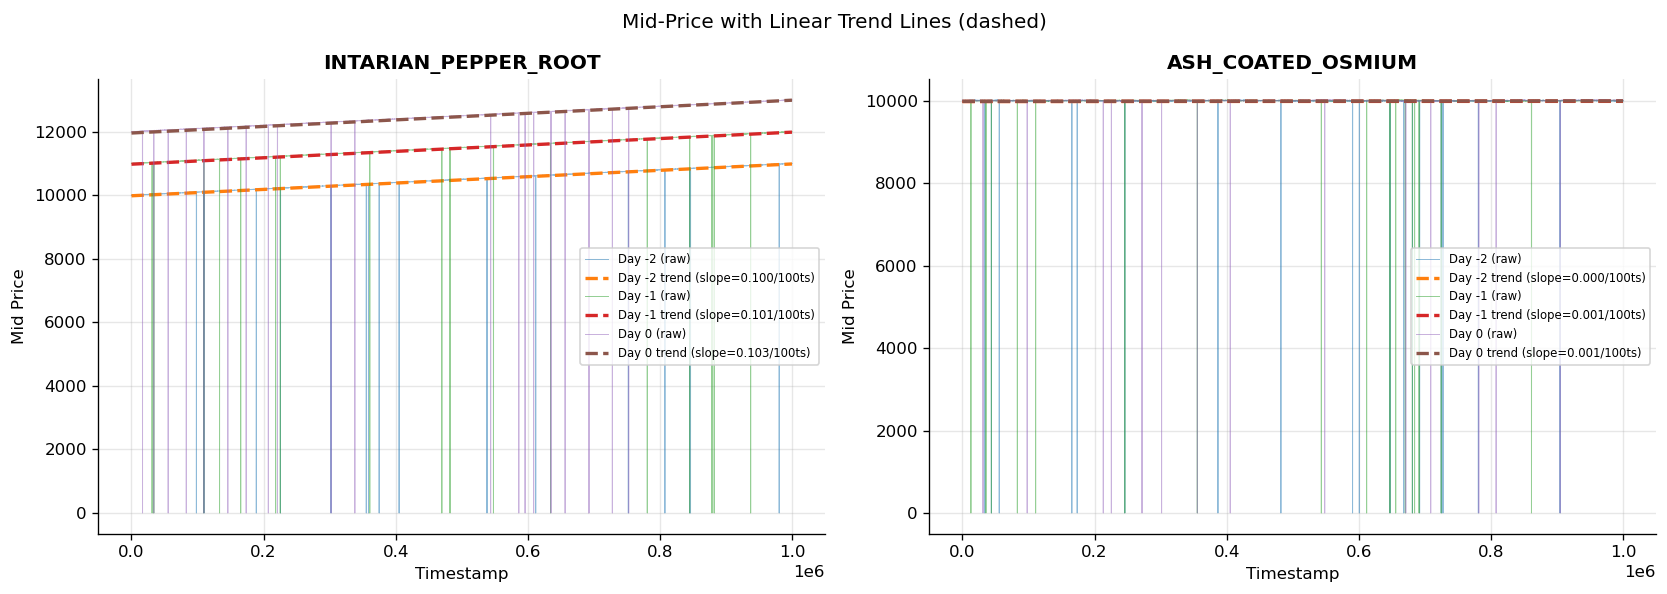

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prod in zip(axes, prices['product'].unique()):
    sub = prices[prices['product'] == prod].dropna(subset=['mid_price'])

    for day, grp in sub.groupby('day'):
        grp = grp.sort_values('timestamp')
        # raw price
        ax.plot(grp['timestamp'], grp['mid_price'], linewidth=0.6,
                alpha=0.5, label=f'Day {day} (raw)')
        # fitted line
        s, intercept, _, _, _ = stats.linregress(grp['timestamp'], grp['mid_price'])
        x_line = np.array([grp['timestamp'].min(), grp['timestamp'].max()])
        y_line = s * x_line + intercept
        ax.plot(x_line, y_line, linewidth=2, linestyle='--',
                label=f'Day {day} trend (slope={s*100:.3f}/100ts)')

    ax.set_title(prod, fontweight='bold')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid Price')
    ax.legend(fontsize=7)

fig.suptitle('Mid-Price with Linear Trend Lines (dashed)', fontsize=12)
plt.tight_layout()
plt.show()


> **What this tells us:**  
> - `INTARIAN_PEPPER_ROOT` rises by roughly **+1,000 price units per day**, very consistently (R² ≈ 0.76 overall).  
>   The per-day slope is ~0.001 per timestamp — almost identical every day, suggesting a structural drift (e.g. fundamental value is rising).  
> - `ASH_COATED_OSMIUM` is essentially **flat** (slope ≈ 0, R² ≈ 0.0001). No trend at all — it just oscillates around ~10,000.  
>
> **Trading implication:**  
> For Pepper, any model ignoring the drift will systematically misprice. You should adjust your fair-value estimate upward by ~0.1 units every 100 timestamps.  
> For Osmium, a pure mean-reversion strategy around 10,000 is appropriate.


## 4. Bid-Ask Spread

Spread = `ask_price_1 − bid_price_1` (best ask minus best bid).  
Only computed when **both** sides of Level 1 are present.


In [9]:
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

print('Spread stats (ask1 - bid1):')
spread_stats = prices.groupby(['product', 'day'])['spread'].describe().round(2)
print(spread_stats[['count', 'mean', 'std', 'min', '50%', 'max']])


Spread stats (ask1 - bid1):
                           count   mean   std  min   50%   max
product              day                                      
ASH_COATED_OSMIUM    -2   9187.0  16.15  2.54  5.0  16.0  21.0
                     -1   9225.0  16.19  2.56  5.0  16.0  21.0
                      0   9232.0  16.18  2.62  5.0  16.0  22.0
INTARIAN_PEPPER_ROOT -2   9216.0  11.99  2.26  2.0  12.0  18.0
                     -1   9219.0  13.01  2.49  2.0  13.0  19.0
                      0   9253.0  14.13  2.67  2.0  14.0  21.0


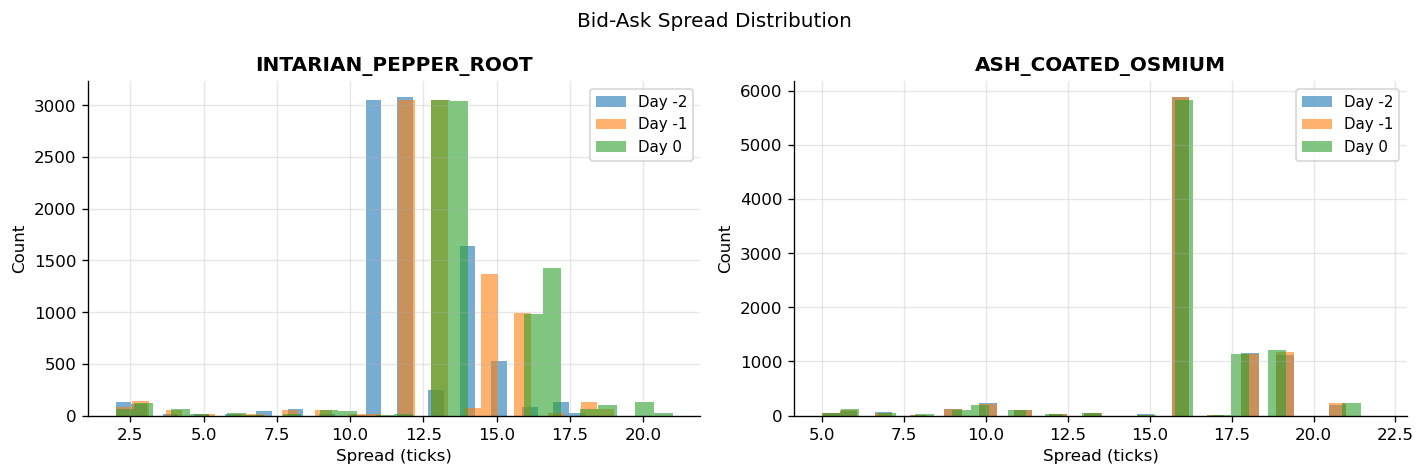

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, prod in zip(axes, prices['product'].unique()):
    sub = prices[prices['product'] == prod].dropna(subset=['spread'])
    for day, grp in sub.groupby('day'):
        ax.hist(grp['spread'], bins=30, alpha=0.6, label=f'Day {day}')
    ax.set_xlabel('Spread (ticks)')
    ax.set_ylabel('Count')
    ax.set_title(prod, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Bid-Ask Spread Distribution', fontsize=12)
plt.tight_layout()
plt.show()


## 5. Order Book Depth Over Time

**Depth at Level 1** = `bid_volume_1 + ask_volume_1`  
A time-series of depth tells us whether the market gets thinner or thicker during the session.


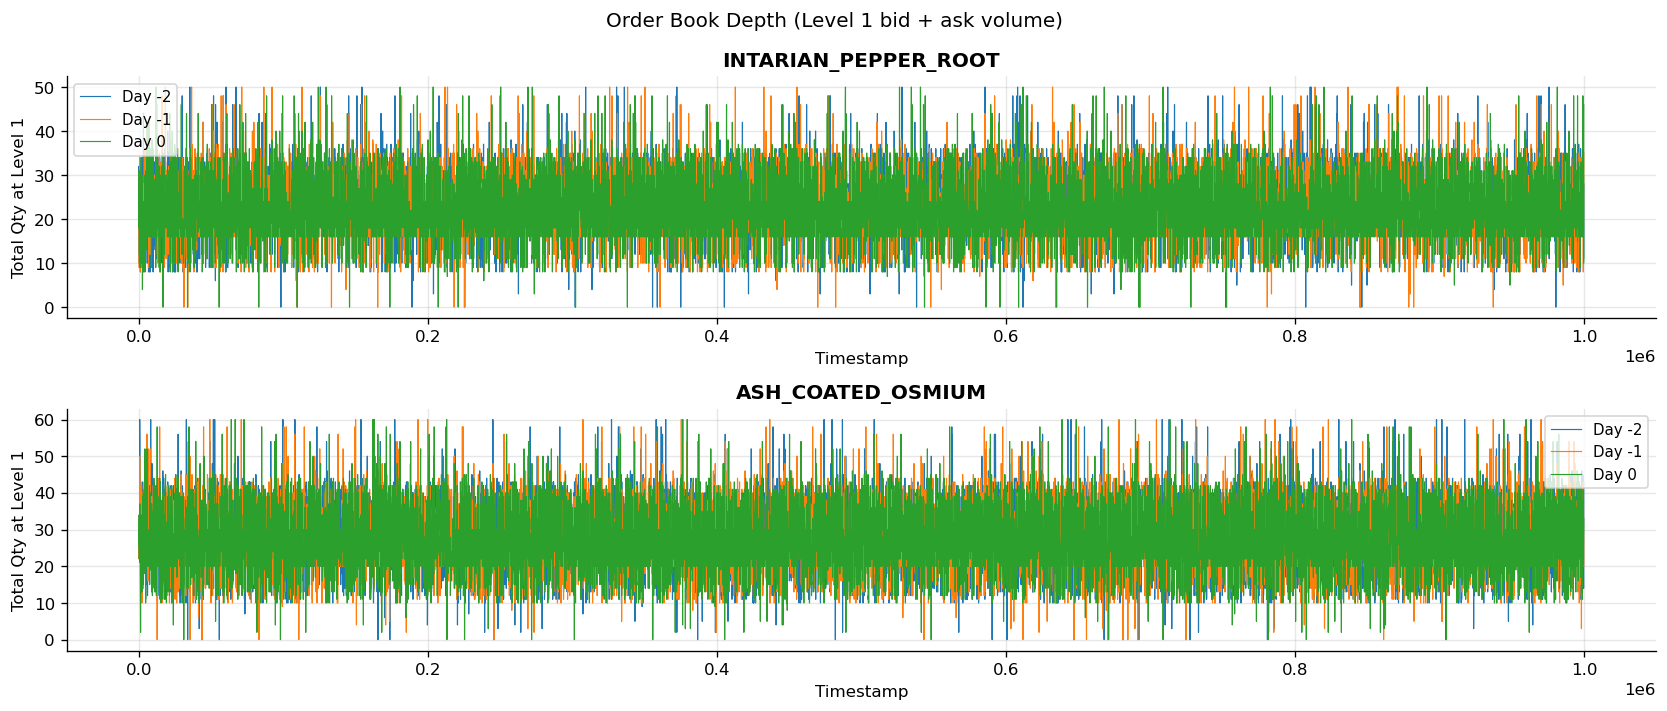

In [11]:
prices['depth_l1'] = prices['bid_volume_1'].fillna(0) + prices['ask_volume_1'].fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, prod in zip(axes, prices['product'].unique()):
    sub = prices[prices['product'] == prod]
    for day, grp in sub.groupby('day'):
        grp = grp.sort_values('timestamp')
        ax.plot(grp['timestamp'], grp['depth_l1'], linewidth=0.7, label=f'Day {day}')
    ax.set_title(prod, fontweight='bold')
    ax.set_ylabel('Total Qty at Level 1')
    ax.set_xlabel('Timestamp')
    ax.legend(fontsize=9)

fig.suptitle('Order Book Depth (Level 1 bid + ask volume)', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Trade Flow Analysis

In [12]:
print('Trade counts per product × day:')
print(trades.groupby(['symbol', 'day'])[['quantity']].agg(['count', 'sum', 'mean']).round(2))
print()
print('Sample rows:')
trades.head()


Trade counts per product × day:


KeyError: 'day'

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
products = trades['symbol'].unique()

# Trade price over time
for i, prod in enumerate(products):
    ax = axes[0, i]
    sub = trades[trades['symbol'] == prod]
    for day, grp in sub.groupby('day'):
        ax.scatter(grp['timestamp'], grp['price'], s=grp['quantity'],
                   alpha=0.6, label=f'Day {day}')
    ax.set_title(f'{prod}\nTrade price (dot size = qty)', fontsize=9, fontweight='bold')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Price')
    ax.legend(fontsize=8)

# Trade volume histogram
for i, prod in enumerate(products):
    ax = axes[1, i]
    sub = trades[trades['symbol'] == prod]
    for day, grp in sub.groupby('day'):
        ax.hist(grp['quantity'], bins=20, alpha=0.6, label=f'Day {day}')
    ax.set_title(f'{prod}\nTrade size distribution', fontsize=9, fontweight='bold')
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Trade Flow', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Key Takeaways

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Level 1 bid/ask present ~96% of the time** | Safe to use best bid/ask as the primary signal |
| 2 | **Level 2 present ~65%, Level 3 ~2%** | Only Level 1 is reliable for quoting; don't build strategies on Level 3 |
| 3 | **INTARIAN_PEPPER_ROOT mid-price drifts up ~+1000 per day** | Strong upward trend — momentum or informed trading |
| 4 | **ASH_COATED_OSMIUM is broadly flat ~10000** | Mean-reverting around a stable fair value — good for market-making |
| 5 | **Spread on ASH_COATED_OSMIUM ≈ 16 ticks, on PEPPER ≈ 12 ticks** | Osmium is wider — higher inventory risk, but larger per-trade profit |
| 6 | **Trade sizes tend to be small (< 10 units)** | Market is not moving in large blocks — retails / bots dominating flow |

---

**Next steps:**  
- For `INTARIAN_PEPPER_ROOT`: model the daily drift and trade with the trend.  
- For `ASH_COATED_OSMIUM`: consider a pure market-making strategy quoting around 10000.
